# Run on google colab only

This notebook is optimized for Google Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ln -sf '/content/drive/MyDrive/piano-chords/svm_gridsearch' '/content/svm_gridsearch'

Mounted at /content/drive


# Define constants

In [3]:
from scipy.stats import loguniform

CLEAN_FEATURES_PATH = "./svm_gridsearch/opus-training.npz"
NOISY_FEATURES_PATH = "./svm_gridsearch/opus-evaluation.npz"
MODEL_SAVE_PATH = "./models"
STORAGE_NAME = "sqlite:///svm_gridsearch/svm_tuning.db"
STUDY_NAME = "RBF_SVM_Tuning-RandomizedSearchCV"
STUDY_OVERRIDE = True
RANDOM_STATE = 42
SVM_TEST_SIZE = 0.1
SVM_CV_FOLDS = 5
SVM_CV_N_ITER = 20
SEARCH_C = [0.1, 1.0, 10.0, 100.0, 1000.0]
SEARCH_GAMMA = [0.000001, 0.00001, 0.0001, 0.001] #  (1 / 40608) = 0.000025
SEARCH_N_TRIALS = 20 # continues from existing search

import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
SVM_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, 'model.pkl')
SVM_SCALER_PATH = os.path.join(MODEL_SAVE_PATH, 'scaler.pkl')
SVM_ENCODER_PATH = os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
import random
import numpy as np
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


# Train with sklearn for compatibility

## Prepare

In [4]:
# Use the values from the best tuned hyperparameter
OPTIMAL_C = 1_000
OPTIMAL_GAMMA = 0.00001

In [5]:
import numpy as np

with np.load(CLEAN_FEATURES_PATH) as data:
    features = data['features']
    labels = data['labels']

print(f"Loaded features shape: {features.shape}")
print(f"Loaded labels shape:   {labels.shape}")

Loaded features shape: (7200, 216, 188)
Loaded labels shape:   (7200,)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Flatten 2D CQT features to 1D for SVM input
features_flat = features.reshape(features.shape[0], -1)

# Encode labels
svm_label_encoder = LabelEncoder()
svm_encoded_labels = svm_label_encoder.fit_transform(labels)

# Train/test split on the sampled data
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    features_flat,
    svm_encoded_labels,
    test_size=SVM_TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=svm_encoded_labels,
)

# Scale features
scaler = StandardScaler()

X_svm_train = scaler.fit_transform(X_svm_train)
X_svm_test = scaler.transform(X_svm_test)

print(f"Original dataset size:  {len(features_flat)}")
print(f"X_svm_train shape:      {X_svm_train.shape}")
print(f"X_svm_test shape:       {X_svm_test.shape}")
print(f"Number of classes:      {len(svm_label_encoder.classes_)}")

Original dataset size:  7200
X_svm_train shape:      (6480, 40608)
X_svm_test shape:       (720, 40608)
Number of classes:      36


## Train final model

In [7]:
from sklearn.svm import SVC

best_svm_model = SVC(
    kernel='rbf',
    C=OPTIMAL_C,
    gamma=OPTIMAL_GAMMA,
    random_state=RANDOM_STATE
)
best_svm_model.fit(X_svm_train, y_svm_train)

SVC(C=1000, gamma=1e-05, random_state=42)

## Evaluate best model

In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_svm_pred = best_svm_model.predict(X_svm_test)

gs_accuracy = accuracy_score(y_svm_test, y_svm_pred)
print(f"Test Accuracy (best model): {gs_accuracy}")

report_gs = classification_report(y_svm_test, y_svm_pred, target_names=svm_label_encoder.classes_)
print("\nClassification Report:\n", report_gs)

Test Accuracy (best model): 1.0

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      1.00      1.00        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminished_4       1.00    

## Confusion Matrix

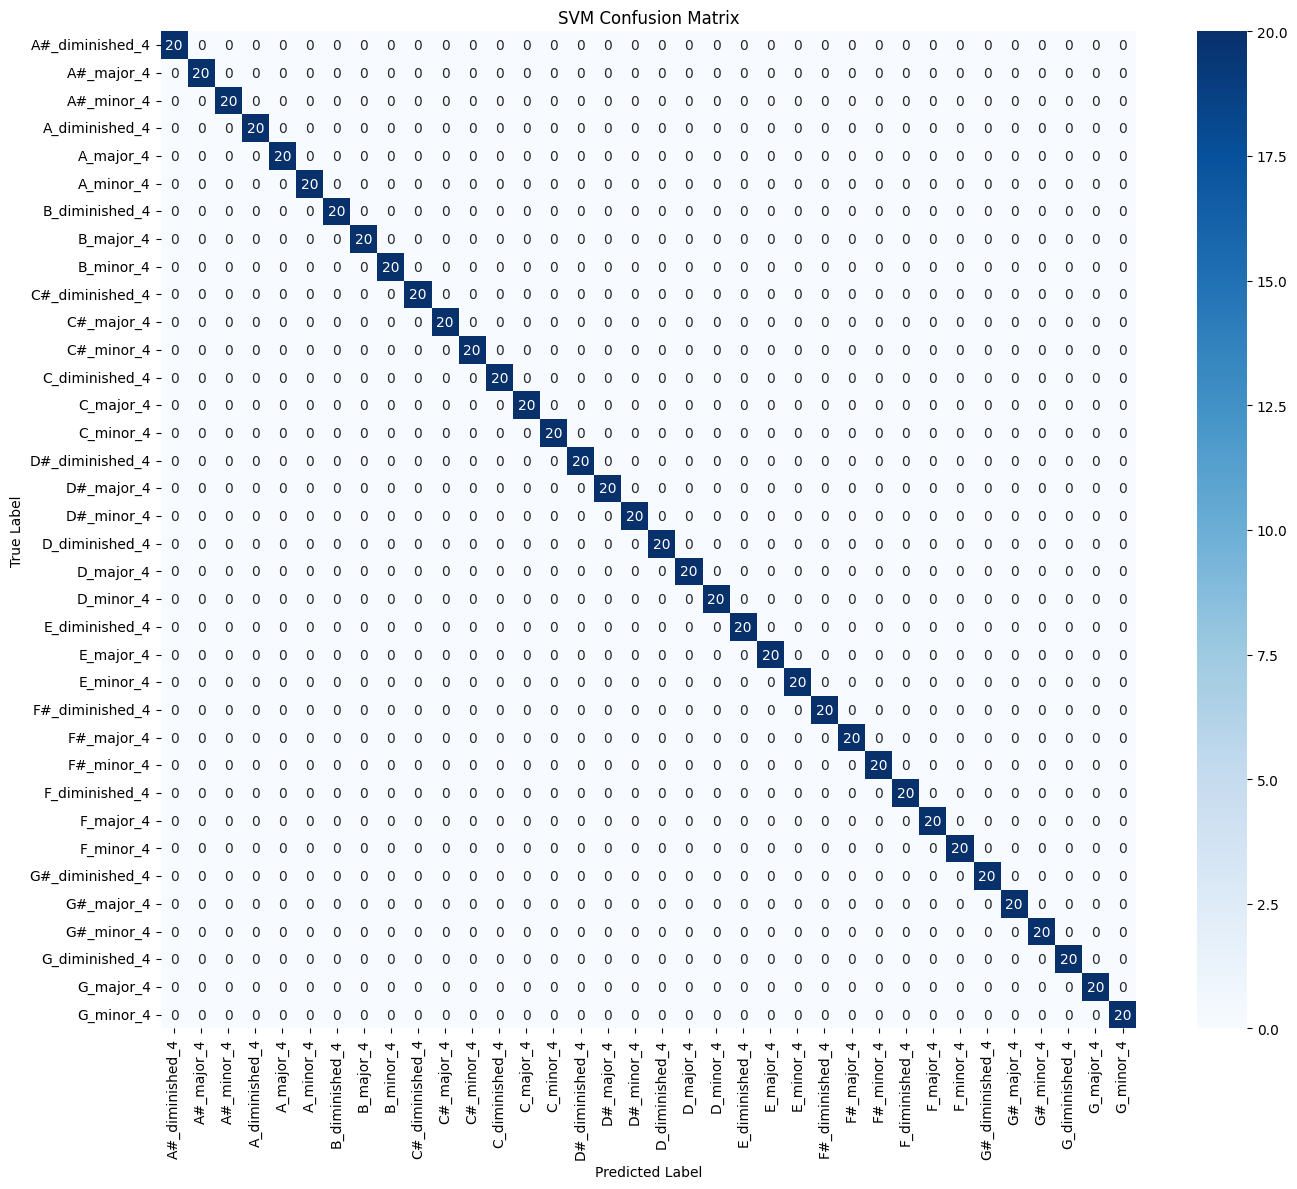

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_svm_test, y_svm_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_label_encoder.classes_, yticklabels=svm_label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'SVM Confusion Matrix')
plt.tight_layout()
plt.show()

## Save SVM Model

In [10]:
import joblib

joblib.dump(best_svm_model, SVM_MODEL_PATH)
joblib.dump(scaler, SVM_SCALER_PATH)
joblib.dump(svm_label_encoder, SVM_ENCODER_PATH)

print(f"SVM model saved to {MODEL_SAVE_PATH}")

SVM model saved to ./models


In [11]:
!zip svm_models.zip models/*

  adding: models/label_encoder.pkl (deflated 83%)
  adding: models/model.pkl (deflated 47%)
  adding: models/scaler.pkl (deflated 13%)


In [12]:
from google.colab import files
files.download('svm_models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# K-Fold Cross-Validation

## Prepare data

In [14]:
# Use the values from the best tuned hyperparameter
OPTIMAL_C = 1_000
OPTIMAL_GAMMA = 0.00001

import numpy as np

with np.load(CLEAN_FEATURES_PATH) as data:
    features = data['features']
    labels = data['labels']

print(f"Loaded features shape: {features.shape}")
print(f"Loaded labels shape:   {labels.shape}")

Loaded features shape: (7200, 216, 188)
Loaded labels shape:   (7200,)


In [15]:
from sklearn.preprocessing import LabelEncoder

# Flatten 2D CQT features to 1D for SVM input
features_flat = features.reshape(features.shape[0], -1)

# Encode labels
svm_label_encoder = LabelEncoder()
svm_encoded_labels = svm_label_encoder.fit_transform(labels)

print(f"Original dataset size:  {len(features_flat)}")
print(f"Features flat shape:    {features_flat.shape}")
print(f"Encoded labels shape:   {svm_encoded_labels.shape}")
print(f"Number of classes:      {len(svm_label_encoder.classes_)}")

Original dataset size:  7200
Features flat shape:    (7200, 40608)
Encoded labels shape:   (7200,)
Number of classes:      36


## Cross validation

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
import gc
from datetime import datetime
import os
import pickle

# 1. CROSS VALIDATION PROCESS
# Note: The dataset has 200 samples per class.
# With 5 folds (SVM_CV_FOLDS=5), each validation fold gets 20% of the data, which is 40 samples per class.
# The test_size=0.1 used earlier does not apply to this K-Fold splitting logic.
print("Starting K-Fold Cross Validation...")

skf = StratifiedKFold(n_splits=SVM_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

CHECKPOINT_FILE = "cv_checkpoint.pkl"

if os.path.exists(CHECKPOINT_FILE):
    print("Loading checkpoint...")
    with open(CHECKPOINT_FILE, "rb") as f:
        checkpoint_data = pickle.load(f)
        fold_metrics = checkpoint_data['fold_metrics']
        confusion_matrices = checkpoint_data['confusion_matrices']
    last_completed_fold = max([m['Fold'] for m in fold_metrics]) if fold_metrics else 0
    print(f"Resuming from fold {last_completed_fold + 1}")
else:
    fold_metrics = []
    confusion_matrices = []
    last_completed_fold = 0

class_names = svm_label_encoder.classes_

for fold, (train_idx, val_idx) in enumerate(skf.split(features_flat, svm_encoded_labels), 1):
    if fold <= last_completed_fold:
        print(f"\n{'-'*20} Fold {fold} {'-'*20}")
        print("Skipping (already completed from checkpoint).")
        continue

    fold_start_time = datetime.now().replace(microsecond=0)
    print(f"\n{'-'*20} Fold {fold} {'-'*20}")
    X_train_cv, X_val_cv = features_flat[train_idx], features_flat[val_idx]
    y_train_cv, y_val_cv = svm_encoded_labels[train_idx], svm_encoded_labels[val_idx]

    # Scale data (fit on training fold only to prevent leakage)
    cv_scaler = StandardScaler()
    X_train_cv = cv_scaler.fit_transform(X_train_cv)
    X_val_cv = cv_scaler.transform(X_val_cv)

    # Train Model
    cv_model = SVC(
        kernel='rbf',
        C=OPTIMAL_C,
        gamma=OPTIMAL_GAMMA,
        random_state=RANDOM_STATE,
        cache_size=512
    )
    cv_model.fit(X_train_cv, y_train_cv)
    fold_duration = datetime.now().replace(microsecond=0) - fold_start_time
    print(f"Train Duration: {fold_duration}")

    y_pred_cv = cv_model.predict(X_val_cv)
    acc = accuracy_score(y_val_cv, y_pred_cv)
    cm = confusion_matrix(y_val_cv, y_pred_cv)

    # Call 1: Get the report as a dictionary to programmatically extract F1 scores
    report_dict = classification_report(y_val_cv, y_pred_cv, target_names=class_names, output_dict=True)

    fold_metrics.append({
        'Fold': fold,
        'Accuracy': acc,
        'Macro F1': report_dict['macro avg']['f1-score'],
        'Weighted F1': report_dict['weighted avg']['f1-score']
    })
    confusion_matrices.append(cm)

    # Save Checkpoint
    with open(CHECKPOINT_FILE, "wb") as f:
        pickle.dump({
            'fold_metrics': fold_metrics,
            'confusion_matrices': confusion_matrices
        }, f)
    print("Checkpoint saved.")

    fold_duration = datetime.now().replace(microsecond=0) - fold_start_time

    print(f"Accuracy: {acc:.4f}")
    print(f"Fold Duration: {fold_duration}")
    print("Classification Report:")
    # Call 2: Get the report as a formatted string to print to the console
    print(classification_report(y_val_cv, y_pred_cv, target_names=class_names))

    # Explicitly free up memory
    del X_train_cv, X_val_cv, y_train_cv, y_val_cv, cv_model, cv_scaler, y_pred_cv, cm
    gc.collect()


Starting K-Fold Cross Validation...

-------------------- Fold 1 --------------------
Train Duration: 0:04:37
Checkpoint saved.
Accuracy: 1.0000
Fold Duration: 0:13:52
Classification Report:
                 precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        40
     A#_major_4       1.00      1.00      1.00        40
     A#_minor_4       1.00      1.00      1.00        40
 A_diminished_4       1.00      1.00      1.00        40
      A_major_4       1.00      1.00      1.00        40
      A_minor_4       1.00      1.00      1.00        40
 B_diminished_4       1.00      1.00      1.00        40
      B_major_4       1.00      1.00      1.00        40
      B_minor_4       1.00      1.00      1.00        40
C#_diminished_4       1.00      1.00      1.00        40
     C#_major_4       1.00      1.00      1.00        40
     C#_minor_4       1.00      1.00      1.00        40
 C_diminished_4       1.00      1.00      1.00        40
      C_ma

## Plot


=== Cross Validation Summary ===
   Fold  Accuracy  Macro F1  Weighted F1
0     1       1.0       1.0          1.0
1     2       1.0       1.0          1.0
2     3       1.0       1.0          1.0
3     4       1.0       1.0          1.0
4     5       1.0       1.0          1.0

Mean Accuracy: 1.00000000 (+/- 0.00000000)


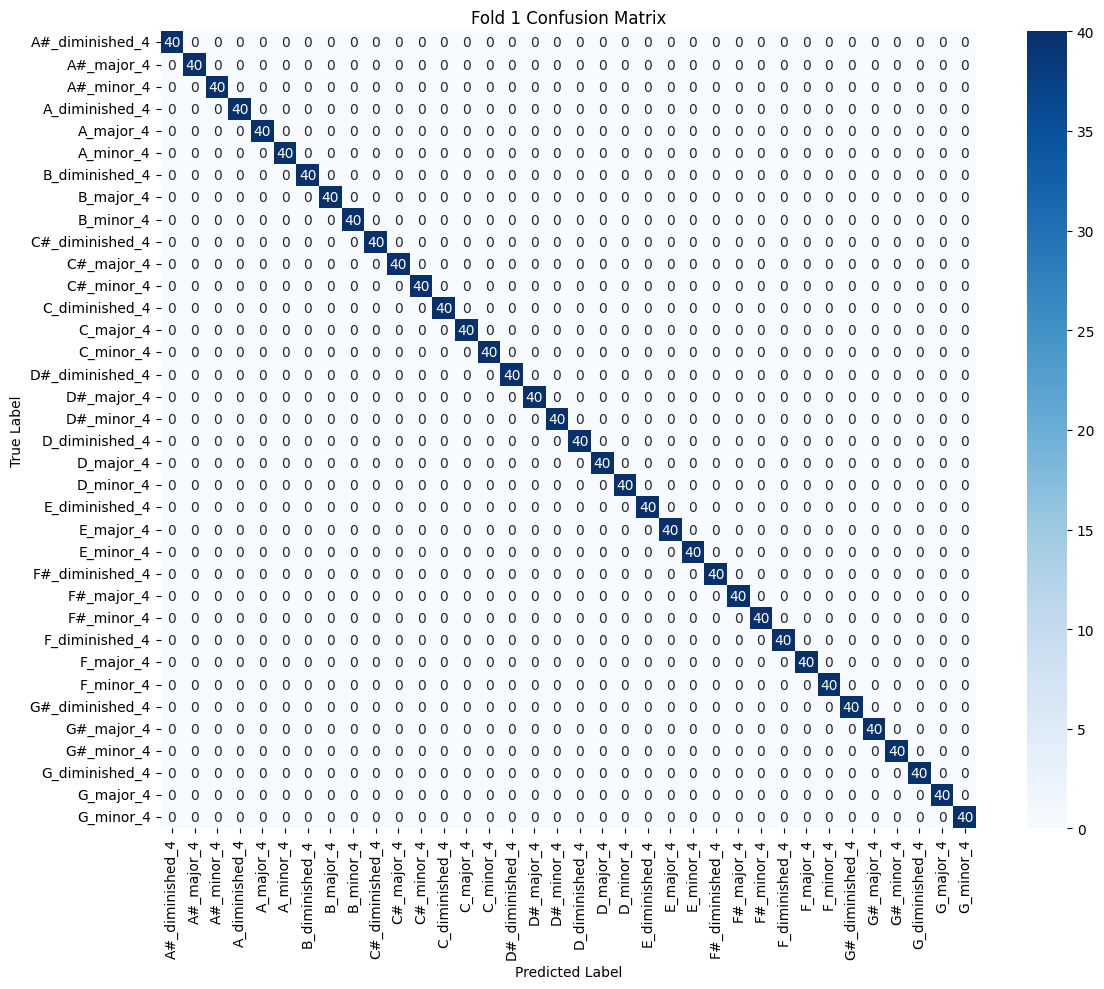

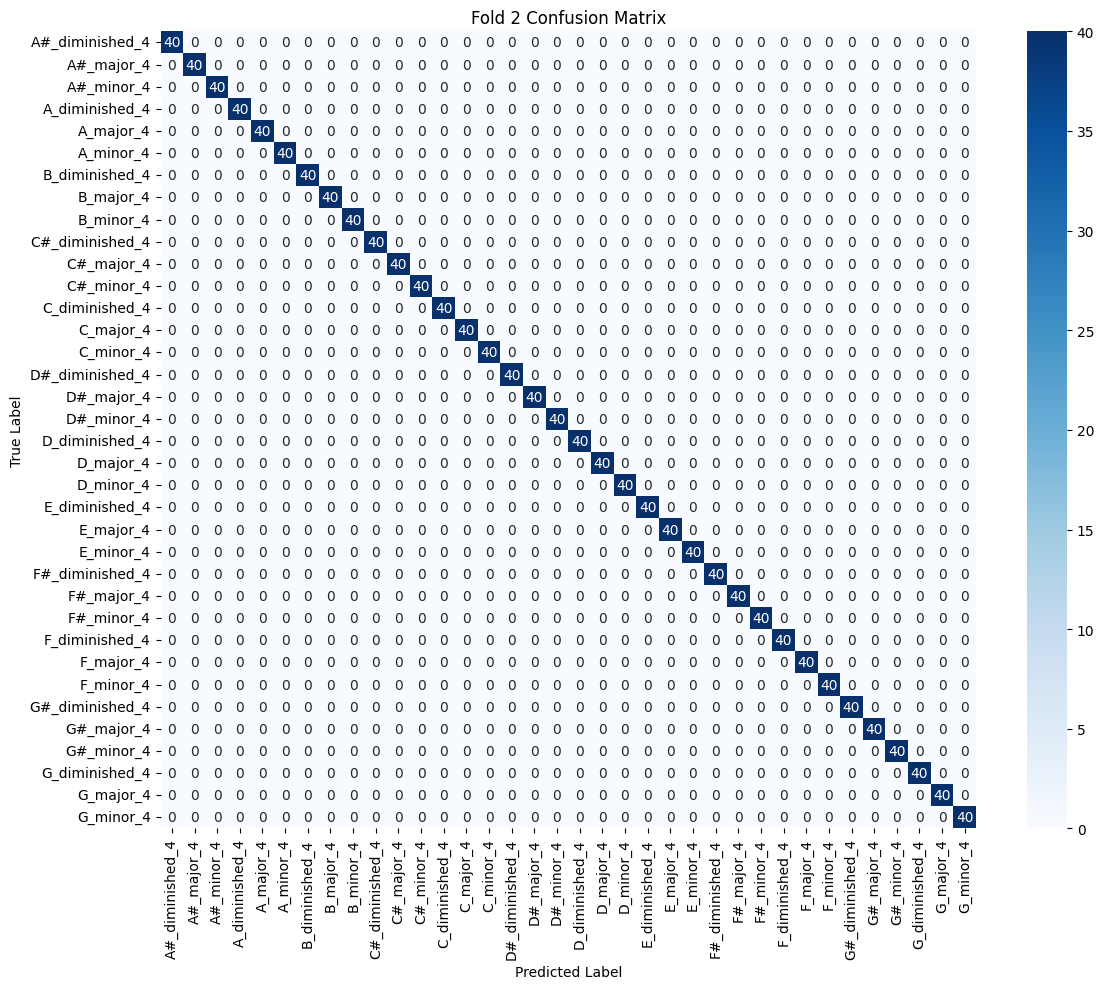

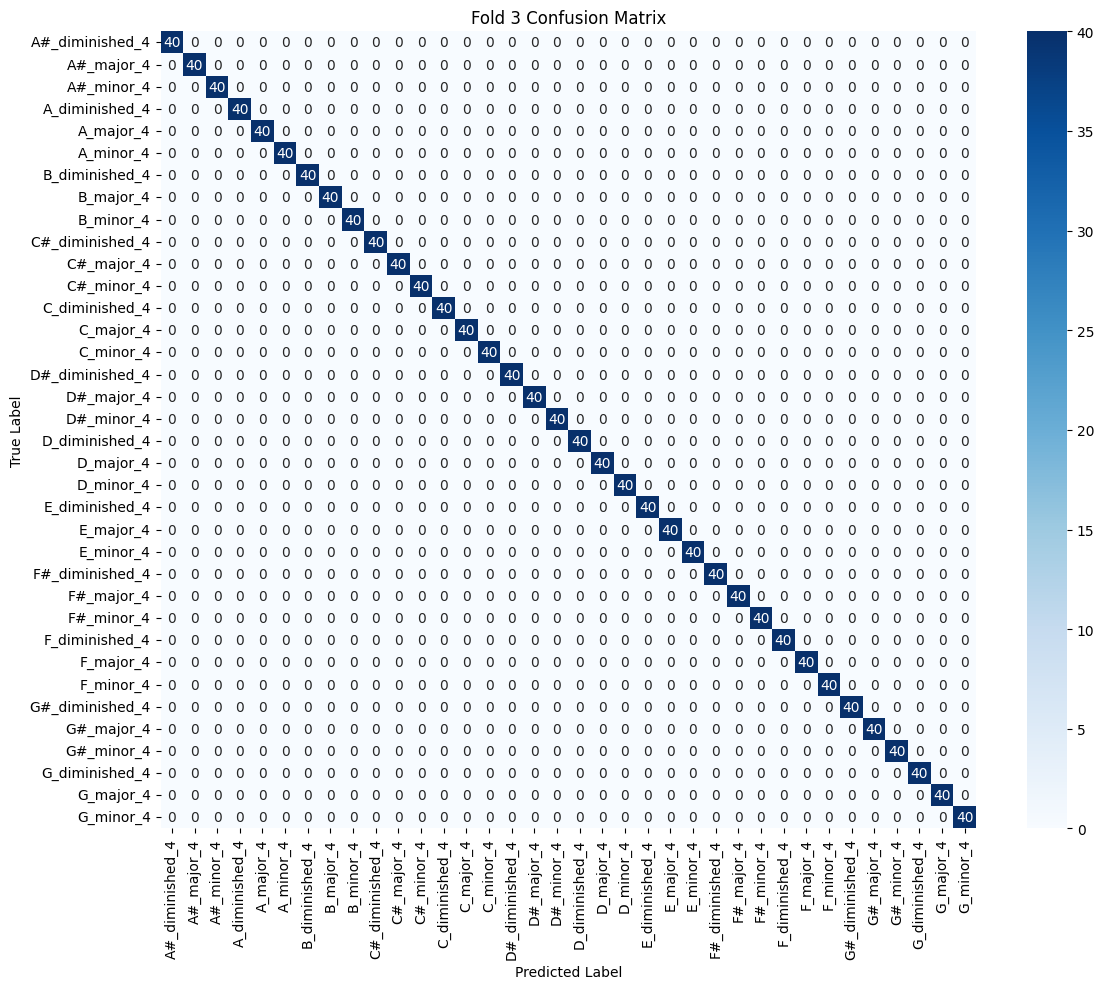

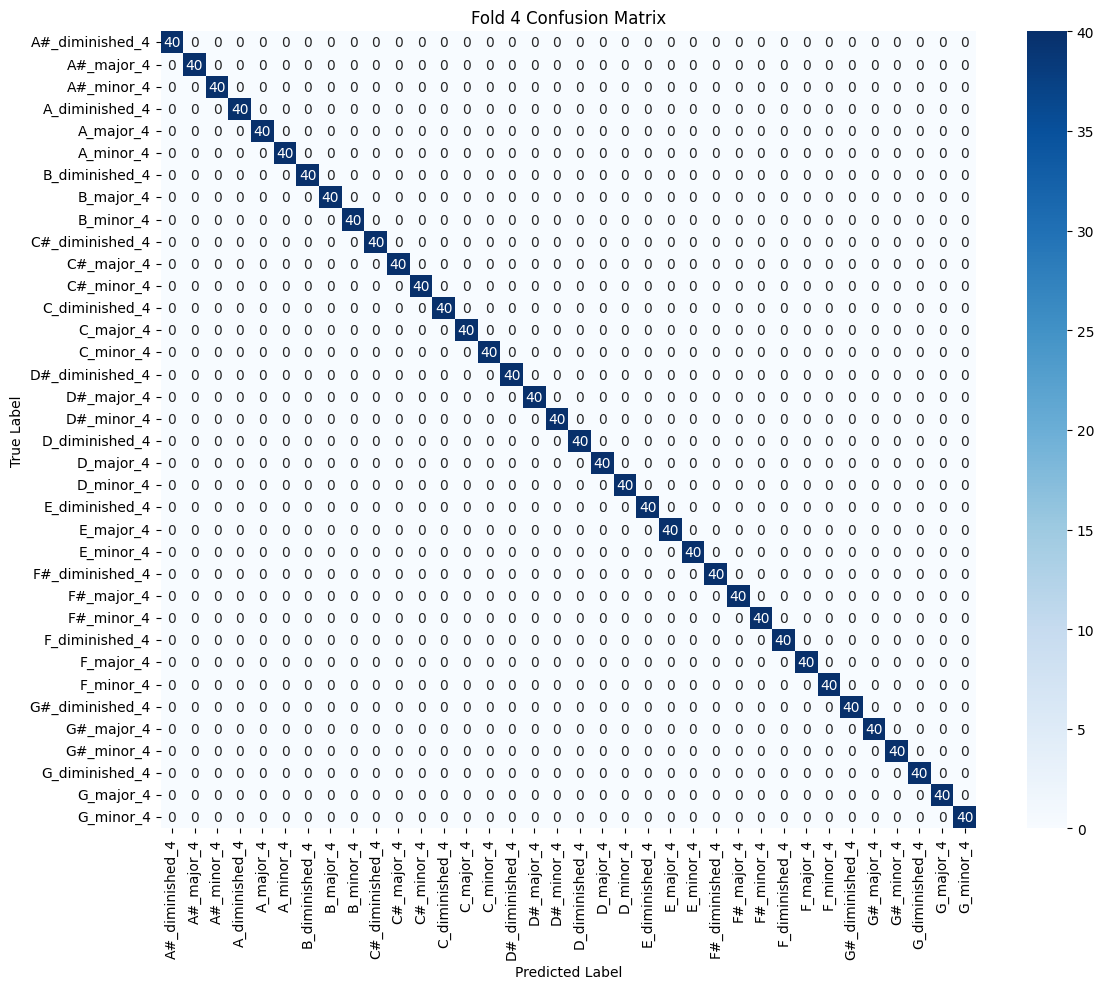

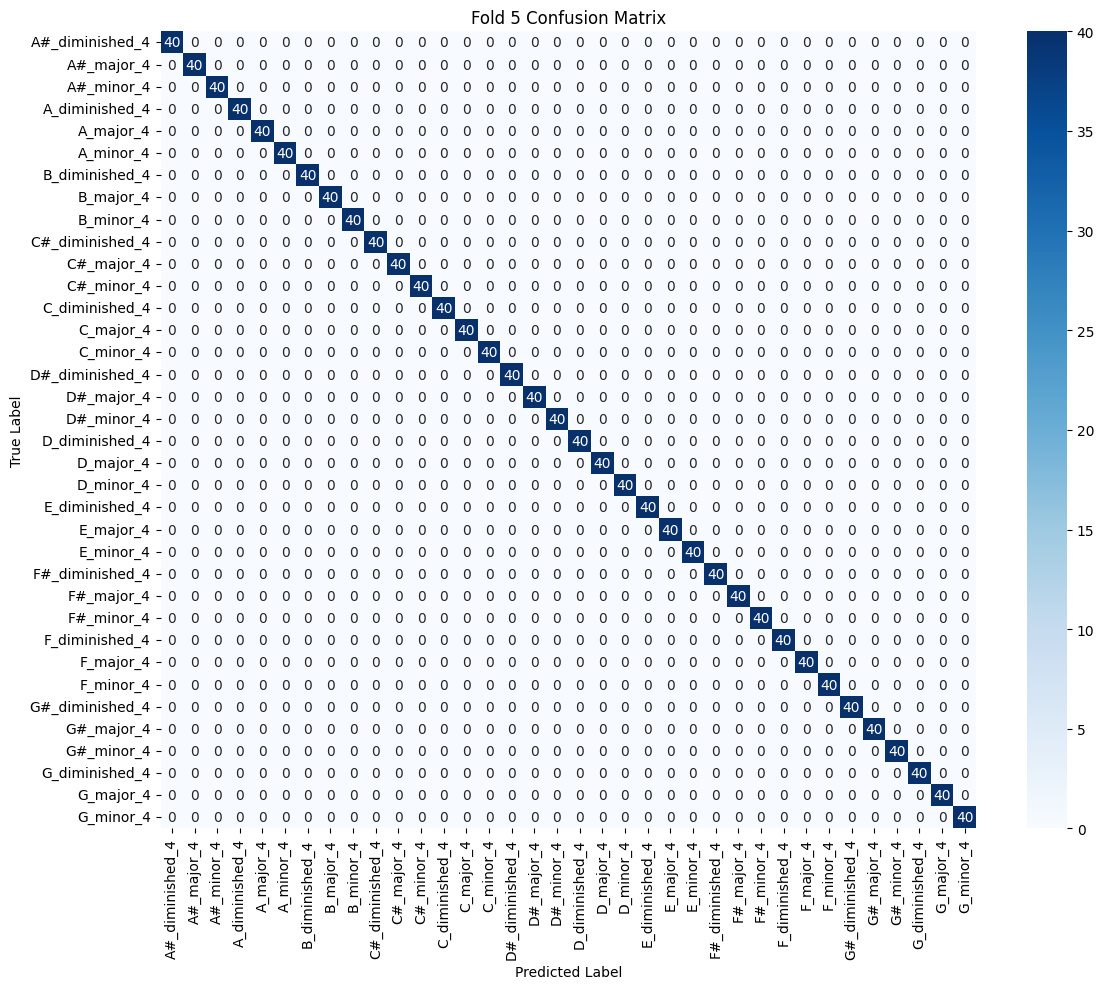

In [17]:
# 2. ACCURACY TABLES & SUMMARY METRICS
print("\n" + "="*40)
print("=== Cross Validation Summary ===")
print("="*40)
metrics_df = pd.DataFrame(fold_metrics)
print(metrics_df)
print(f"\nMean Accuracy: {metrics_df['Accuracy'].mean():.8f} (+/- {metrics_df['Accuracy'].std():.8f})")

# 3. PLOT CONFUSION MATRICES
for i, cm in enumerate(confusion_matrices):
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Fold {i+1} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()


# Test Noisy

## Load Model & Noisy Features

In [18]:
import joblib

svm_model = joblib.load(SVM_MODEL_PATH)
svm_scaler = joblib.load(SVM_SCALER_PATH)
svm_label_encoder = joblib.load(SVM_ENCODER_PATH)
noisy_data = np.load(NOISY_FEATURES_PATH)
noisy_features = noisy_data['features']
noisy_labels = noisy_data['labels']

print(f"SVM model loaded from {MODEL_SAVE_PATH}")
print(f"Classes: {svm_label_encoder.classes_}")

SVM model loaded from ./models
Classes: ['A#_diminished_4' 'A#_major_4' 'A#_minor_4' 'A_diminished_4' 'A_major_4'
 'A_minor_4' 'B_diminished_4' 'B_major_4' 'B_minor_4' 'C#_diminished_4'
 'C#_major_4' 'C#_minor_4' 'C_diminished_4' 'C_major_4' 'C_minor_4'
 'D#_diminished_4' 'D#_major_4' 'D#_minor_4' 'D_diminished_4' 'D_major_4'
 'D_minor_4' 'E_diminished_4' 'E_major_4' 'E_minor_4' 'F#_diminished_4'
 'F#_major_4' 'F#_minor_4' 'F_diminished_4' 'F_major_4' 'F_minor_4'
 'G#_diminished_4' 'G#_major_4' 'G#_minor_4' 'G_diminished_4' 'G_major_4'
 'G_minor_4']


## Test SVM Model

SVM Test Accuracy on Noisy Dataset: 0.027778

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       0.00      0.00      0.00       100
     A#_major_4       0.00      0.00      0.00       100
     A#_minor_4       0.00      0.00      0.00       100
 A_diminished_4       0.00      0.00      0.00       100
      A_major_4       0.00      0.00      0.00       100
      A_minor_4       0.00      0.00      0.00       100
 B_diminished_4       0.00      0.00      0.00       100
      B_major_4       0.00      0.00      0.00       100
      B_minor_4       0.00      0.00      0.00       100
C#_diminished_4       0.00      0.00      0.00       100
     C#_major_4       0.00      0.00      0.00       100
     C#_minor_4       0.00      0.00      0.00       100
 C_diminished_4       0.03      1.00      0.05       100
      C_major_4       0.00      0.00      0.00       100
      C_minor_4       0.00      0.00      0.00       100
D#_diminished_4  

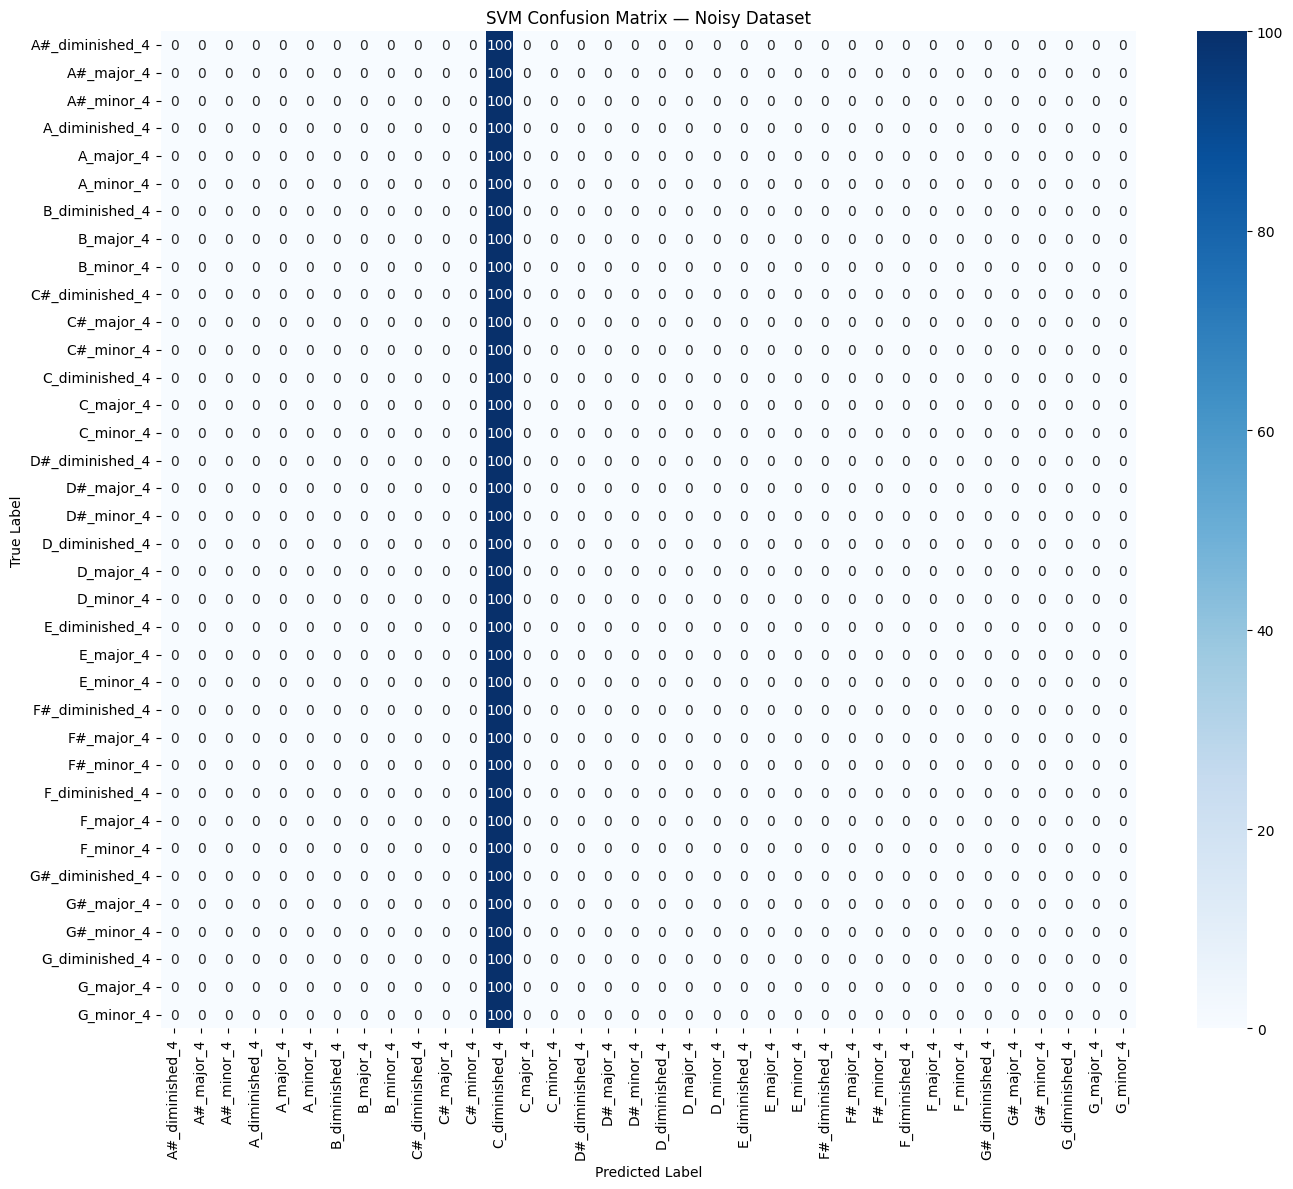

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten and scale noisy features the same way as training data
noisy_features_flat   = noisy_features.reshape(noisy_features.shape[0], -1)
noisy_features_scaled = svm_scaler.transform(noisy_features_flat)

# Encode noisy labels using the loaded label encoder
noisy_svm_encoded = svm_label_encoder.transform(noisy_labels)

# Predict
y_noisy_pred = svm_model.predict(noisy_features_scaled)

# Accuracy & report
noisy_svm_accuracy = accuracy_score(noisy_svm_encoded, y_noisy_pred)
print(f"SVM Test Accuracy on Noisy Dataset: {noisy_svm_accuracy:.6f}")

svm_class_labels = svm_label_encoder.classes_
report_noisy_svm = classification_report(noisy_svm_encoded, y_noisy_pred, target_names=svm_class_labels, zero_division=0)
print("\nClassification Report:\n", report_noisy_svm)

# Confusion matrix
cm_noisy_svm = confusion_matrix(noisy_svm_encoded, y_noisy_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_noisy_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix — Noisy Dataset')
plt.tight_layout()
plt.show()